In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#reading csv and handling null values
df_subject = pd.read_csv('subject-info.csv').dropna(subset=['Age', 'Height', 'Weight'])
df_test = pd.read_csv('test_measure.csv').dropna(subset=['HR', 'RR', 'Speed'])

In [21]:
#34. Create an array , np.arange(12).reshape(3,4). Replace the array elements with their square values if the element is an even number. Keep the odd numbers as such. Display the resulting array.

# Creating an array
array_original=np.arange(12).reshape(3,4)

#Using np.where condition
resulting_array=np.where(array_original%2==0, np.square(array_original), array_original)

print(resulting_array)

[[  0   1   4   3]
 [ 16   5  36   7]
 [ 64   9 100  11]]


In [23]:
#35. Read 10 records from dataframe and convert into json format and print the data

first_ten_records=df_subject.head(10)

#converting into JSON Format
json_data = first_ten_records.to_json(orient='records', lines=True)
print(json_data)

{"Age":10.8,"Weight":48.8,"Height":163.0,"Humidity":39.0,"Temperature":20.7,"Sex":1,"ID":543,"ID_test":"543_1"}
{"Age":11.8,"Weight":41.0,"Height":150.0,"Humidity":41.0,"Temperature":22.3,"Sex":1,"ID":11,"ID_test":"11_1"}
{"Age":12.2,"Weight":46.0,"Height":160.0,"Humidity":37.0,"Temperature":21.5,"Sex":0,"ID":829,"ID_test":"829_1"}
{"Age":13.2,"Weight":71.0,"Height":190.0,"Humidity":49.0,"Temperature":23.8,"Sex":1,"ID":284,"ID_test":"284_1"}
{"Age":13.7,"Weight":53.8,"Height":169.7,"Humidity":40.0,"Temperature":25.3,"Sex":0,"ID":341,"ID_test":"341_1"}
{"Age":13.8,"Weight":53.4,"Height":171.0,"Humidity":42.0,"Temperature":24.4,"Sex":0,"ID":341,"ID_test":"341_2"}
{"Age":14.0,"Weight":46.0,"Height":160.0,"Humidity":40.0,"Temperature":25.3,"Sex":0,"ID":343,"ID_test":"343_1"}
{"Age":14.1,"Weight":50.0,"Height":168.9,"Humidity":42.0,"Temperature":24.2,"Sex":0,"ID":330,"ID_test":"330_1"}
{"Age":14.1,"Weight":47.2,"Height":160.2,"Humidity":40.0,"Temperature":25.2,"Sex":0,"ID":338,"ID_test":"33

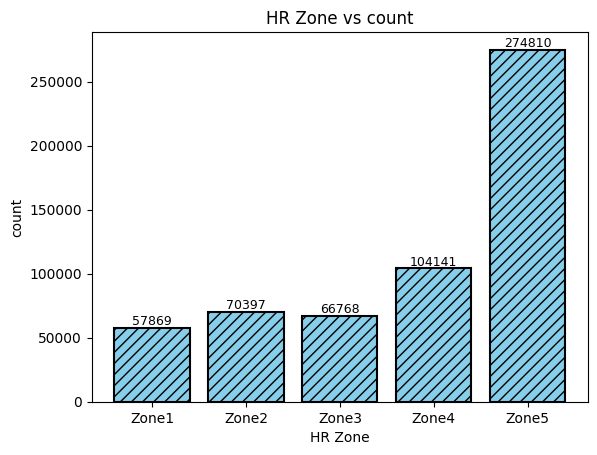

In [22]:
#36. Create a barchart for HR Zone vs count and apply hatches to the bars.

#removing rows that has missing values in HR Column
df_test = df_test.dropna(subset=['HR']) 

#hr-zones based on Q)23
def hr_zones(hr):
    if hr<100:
        return "Zone1"   #-(recovery/easy)
    elif hr<120:
        return "Zone2"   #-(aerobic/base)
    elif hr<135:
        return "Zone3"   #-(tempo)
    elif hr<155:
        return "Zone4"   #-(lactate threshold)
    else:
        return "Zone5"   #-(anaerobic)

#applying to each row
df_test['hr_zones']=df_test['HR'].apply(hr_zones)

#count of zone in each row
count_of_zone = df_test['hr_zones'].value_counts().sort_index()

# Plotting Bar Chart
bars = plt.bar(count_of_zone.index, count_of_zone.values,hatch='///', color='skyblue', edgecolor='black', linewidth=1.5)

# Label the bars
for bar in bars:
    yval = bar.get_height()  # Get the height (value) of each bar
    plt.text(bar.get_x() + bar.get_width()/2, yval + 2, str(int(yval)), 
             ha='center', va='bottom', fontsize=9)

#Plotting Bar Chart
plt.xlabel("HR Zone") 
plt.ylabel("count")
plt.title("HR Zone vs count")
plt.show()

In [25]:
#37.Who is the youngest athlete and how many tests did she take part in?

#Only rows where gender is female which is 1
female_athlete = df_subject[df_subject['Sex'] == 1]

#youngest athlete whose age is minimum
youngest_athlete = female_athlete['Age'].min()

#finding the youngest female athlete row
youngest_female_athlete=female_athlete[female_athlete['Age'] == youngest_athlete].iloc[0]

#getting her ID
youngest_female_athlete_ID=youngest_female_athlete['ID']

print(f"Youngest female athlete ID is:{youngest_female_athlete_ID} and her age is {youngest_athlete}")

#no of tests she took part 
no_of_tests = df_test[df_test['ID'] == youngest_female_athlete_ID]
total_tests = no_of_tests.shape[0]

print(f"No of tests She took part in: {total_tests}")

Youngest female athlete ID is:543 and her age is 10.8
No of tests She took part in: 673


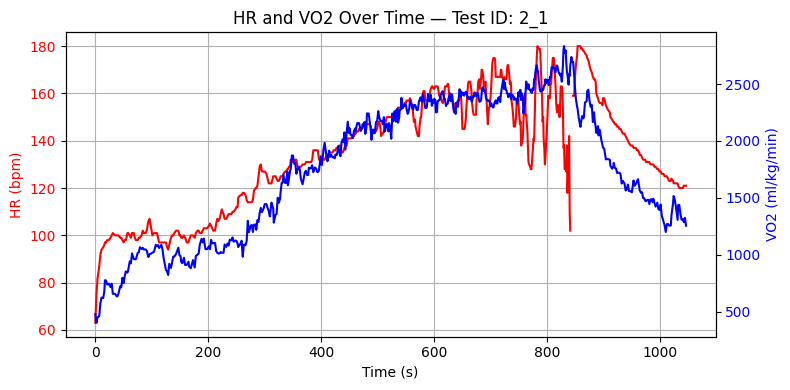

In [91]:
#38.Plot the changes in HR and VO2 over time for each ID_test. Add a trendline to compare the HR and VO2 changes.

# Step 2: Pick one test ID
test_id = df_test['ID_test'].dropna().unique()[0]
df_test = df_test[df_test['ID_test'] == test_id]

#plotting
fig, axis1 = plt.subplots(figsize=(8, 4))

# Plot HR on primary y-axis
axis1.plot(df_test['time'], df_test['HR'], color='red', label='HR')
axis1.set_xlabel('Time (s)')
axis1.set_ylabel('HR (bpm)', color='red')
axis1.tick_params(axis='y', labelcolor='red')

# Plot VO2 on secondary y-axis
axis2 = axis1.twinx()
axis2.plot(df_test['time'], df_test['VO2'], color='blue', label='VO2')
axis2.set_ylabel('VO2 (ml/kg/min)', color='blue')
axis2.tick_params(axis='y', labelcolor='blue')

# Title and Grid
plt.title(f'HR and VO2 Over Time — Test ID: {test_id}')
axis1.grid(True)
plt.tight_layout()
plt.show()        

#since there are 992 tests, we are plotting for single test. We can do the same for all tests

In [72]:
#39.Find the average HRV for individual athletes, using short-term variability analysis(RMSSD).
#Used to measure Heart Rate Variability (HRV), how much heart rate changes from beat to beat

df_test = pd.read_csv('test_measure.csv').dropna(subset=['RR'])

#calculating RMSSD
def func_rmssd(rr_interval_values):
    # difference between RR values
    diff_rr = np.diff(rr_interval_values)    
    #Square the differences
    squared_difference = diff_rr**2    
    #mean of squared differences and applying square root
    rmssd = np.sqrt(np.mean(squared_difference))
    return rmssd

#calculate rmssd for each athlete
athlete_rmssd = df_test.groupby('ID')['RR'].apply(func_rmssd)

# rmssd dataFrame for display
rmssd_df = athlete_rmssd.reset_index()
rmssd_df.columns = ['ID', 'RMSSD']

#result
print("Average HRV per athlete:")
print(rmssd_df)

Average HRV per athlete:
      ID     RMSSD
0      1  0.974321
1      2  1.243954
2      3  2.000829
3      4  1.607636
4      5  1.461686
..   ...       ...
852  853  1.418076
853  854  1.649630
854  855  1.441412
855  856  2.802726
856  857  1.631976

[857 rows x 2 columns]


In [ ]:
#40. Identify the test that took the longest time to complete.

#max time per test
test_durations = df_test.groupby('ID_test')['time'].max()

#test with the longest time
longest_test_id = test_durations.idxmax()
longest_time = test_durations.max()

print("Test that took Longest Time to complete:")
print(f"Test ID: {longest_test_id} and  Duration: is {longest_time} seconds")

Test that took Longest Time to complete:
Test ID: 699_1 and  Duration: is 1712 seconds


In [28]:

#41. Perform an EDA of subject_info using YDATA Profiling.

###Use python version below 3.13.0

###Installing the package
#pip install ydata-profiling

###Import the libraries
#import pandas as pd
#from ydata_profiling import ProfileReport

###Read the data
#df_subject = pd.read_csv("subject_info.csv")

###Generate Profile Report
###subject_info_report = ProfileReport(df_subject, title="EDA of subject_info", explorative=True)
#subject_info_report = ProfileReport(df_subject, title = "EDA of subject_info")

###subject_info_report.to_file(output_file = 'Report_subject_info.html')
###For Jupyter Notebook -profile.to_notebook_iframe()

### Display the report in the notebook
#subject_info_report.to_notebook_iframe()


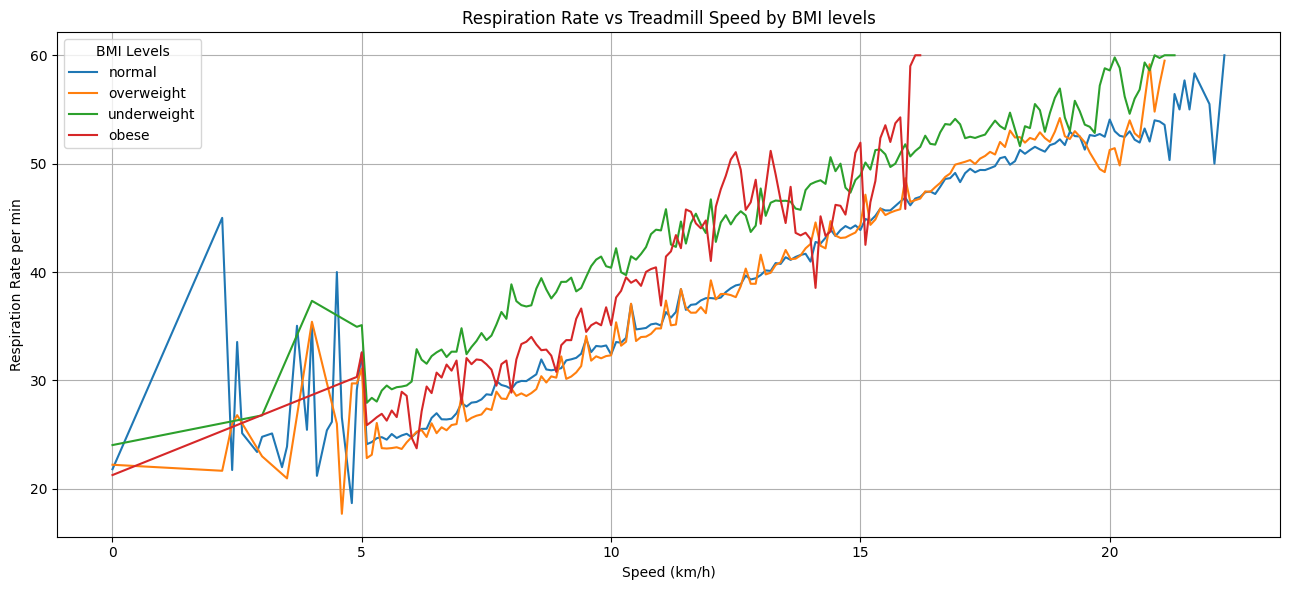


 *BMI level with highest average respiratory rate is:*
underweight level with 39.82 per min


In [29]:
#42.How does respiration rate progress based on treadmill speed for different BMI levels? Visualize this relationship and find which BMI level has the highest mean respiration rate?"

# Convert height from cm to meters
df_subject['Height_m'] = df_subject['Height'] / 100

# Calculate BMI
df_subject['BMI'] = df_subject['Weight'] / (df_subject['Height_m'] ** 2)

#merge on participant ID
df_merge = pd.merge(df_test,df_subject, on='ID')

#BMI Levels
def bmi_levels(bmi):
    if bmi<18.5:
        return 'underweight'
    elif bmi<25:
        return 'normal'
    elif bmi<30:
        return 'overweight'
    else:
        return 'obese'
   
df_merge['BMI levels'] = df_merge['BMI'].apply(bmi_levels)

#visualizing relation between respiration rate and treadmill
plt.figure(figsize=(13,6))
sns.lineplot(data=df_merge, x='Speed', y='RR', hue='BMI levels',errorbar=None)
plt.title("Respiration Rate vs Treadmill Speed by BMI levels")
plt.xlabel("Speed (km/h)")
plt.ylabel("Respiration Rate per min")
plt.legend(title="BMI Levels")
plt.grid(True)
plt.tight_layout()
plt.show()

#BMI level with highest average Resp Rate
mean_highest_avg_rr = df_merge.groupby('BMI levels')['RR'].mean()

print("\n *BMI level with highest average respiratory rate is:*")
print(f"{mean_highest_avg_rr.idxmax()} level", "with", round(mean_highest_avg_rr.max(), 2), "per min")


In [ ]:
#43. Identify cases of possible bradycardia at rest and display number of athletes based on gender.

#bradycardia - slow heart rate<60
bradycardia_df = df_test[df_test['HR'] < 60]

#no.of athletes based on gender
no_of_athletes=df_merge['Sex'].value_counts()

print("No of athletes with possible bradycardia cases are:")
print(no_of_athletes)

No of athletes with possible bradycardia cases are:
Sex
0    675573
1     96665
Name: count, dtype: int64


In [ ]:
#Repeating same question 2nd time, will delete later once the right solution is confirmed
#43. Identify cases of possible bradycardia at rest and display number of athletes based on gender.

#bradycardia - slow heart rate<60
bradycardia_df = df_test[df_test['HR'] < 60]

df_merge['Gender'] = df_merge['Sex'].map({0: 'Male:0', 1: 'Female:1'})

#no.of athletes based on gender
no_of_athletes=df_merge['Gender'].value_counts()

print(f"no of athletes with possible bradycardia cases are:")
print(no_of_athletes)

no of athletes with possible bradycardia cases are:
Gender
Male:0      675573
Female:1     96665
Name: count, dtype: int64


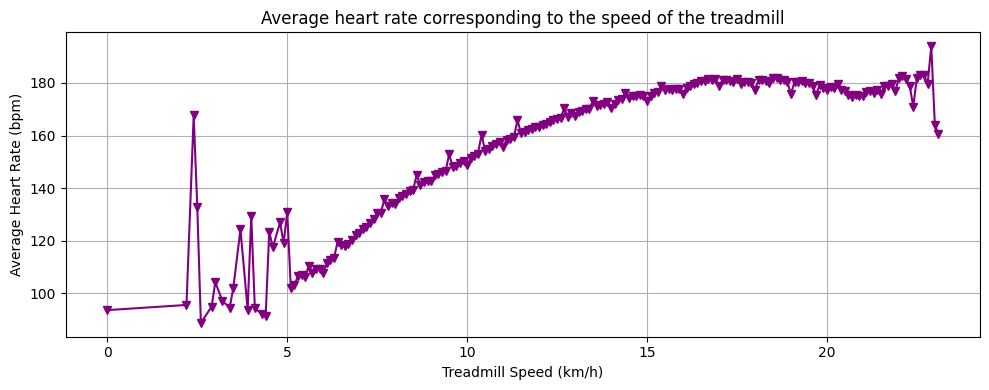

In [33]:
#44. Calculate the average heart rate corresponding to the speed of the treadmill and  plot a line graph to visualize the relationship.

avg_heart_rate=df_test.groupby('Speed')['HR'].mean()

#plotting the line graph
plt.figure(figsize=(10,4))
plt.plot(avg_heart_rate.index,avg_heart_rate.values, marker='v', linestyle='-', color='purple')
plt.title("Average heart rate corresponding to the speed of the treadmill")
plt.xlabel("Treadmill Speed (km/h)")
plt.ylabel("Average Heart Rate (bpm)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [62]:
#45. Analyze the trend of HR at the start of the test vs the middle and the end. What is the overall trend?
# Drop missing HR
df_test = df_test.dropna(subset=['HR'])  

# storing mean HR for each test
start_test_mean = []
middle_test_mean = []
end_test_mean = []

#for each test
for test_id in df_test['ID_test'].unique():
    test_data = df_test[df_test['ID_test'] == test_id].sort_values('time').reset_index(drop=True)
    n = len(test_data)   
    if n >= 3:  
        one_third = n // 3
        #slicing
        start_test_slice = test_data.iloc[:one_third]
        middle_test_slice = test_data.iloc[one_third:2*one_third]
        end_test_slice = test_data.iloc[2*one_third:]

        start_test_mean.append(start_test_slice['HR'].mean())
        middle_test_mean.append(middle_test_slice['HR'].mean())
        end_test_mean.append(end_test_slice['HR'].mean())

#summary
overall_trend = pd.DataFrame({
    'Start_test': start_test_mean,
    'Middle_test': middle_test_mean,
    'End_test': end_test_mean})

# Overall average trend
overall_mean = overall_trend.mean()
print("\n Overall Avg HR trend (bpm) across tests:")
print("HR increases in the middle of the test and drops at the end of test")
print(overall_mean.to_dict())



 Overall Avg HR trend (bpm) across tests:
HR increases in the middle of the test and drops at the end of test
{'Start_test': 116.07004426937901, 'Middle_test': 164.61197550859268, 'End_test': 160.41864187082422}


In [37]:
#46. Find the oldest athlete in the dataset and determine the number of breaths recorded for the oldest athlete during the test.

oldest_athelete = df_subject[df_subject['Age'] == df_subject['Age'].max()]
oldest_id = oldest_athelete['ID'].values[0]

#breathe of oldest athlete
breath_count = df_test[df_test['ID'] == oldest_id]['RR'].count()

print(f"\n Number of breaths recorded for the oldest athlete during the test: {breath_count}")


 Number of breaths recorded for the oldest athlete during the test: 345


In [38]:
#47Assuming age is given for the current year(2025),list the participants born on leap year

#calculate year of birth
df_subject['Year of Birth']= 2025 - df_subject['Age']

#leap year
def leap_year(year):
    if year % 4 == 0:
        if year % 100 == 0:
            if year % 400 == 0:
                return True
            else:
                return False
        return True
    return False

df_subject['leap_year_born'] = df_subject['Year of Birth'].apply(leap_year)

#participants born in leap year
leap_year_participants=df_subject[df_subject['leap_year_born'] == True]

#list of participants
print("Participants born in leap years:")
print(leap_year_participants[['ID', 'Age', 'Year of Birth']])

Participants born in leap years:
      ID   Age  Year of Birth
113  177  17.0         2008.0
114  303  17.0         2008.0
115  346  17.0         2008.0
116  637  17.0         2008.0
244   83  21.0         2004.0
245  458  21.0         2004.0
246  773  21.0         2004.0
404   84  25.0         2000.0
405  183  25.0         2000.0
406  255  25.0         2000.0
407  263  25.0         2000.0
408  353  25.0         2000.0
409  391  25.0         2000.0
410  493  25.0         2000.0
555  491  29.0         1996.0
556  566  29.0         1996.0
557  857  29.0         1996.0
664  103  33.0         1992.0
665  763  33.0         1992.0
764   95  37.0         1988.0
765  196  37.0         1988.0
766  236  37.0         1988.0
767  253  37.0         1988.0
768  630  37.0         1988.0
769  632  37.0         1988.0
852  101  41.0         1984.0
853  363  41.0         1984.0
917  450  45.0         1980.0


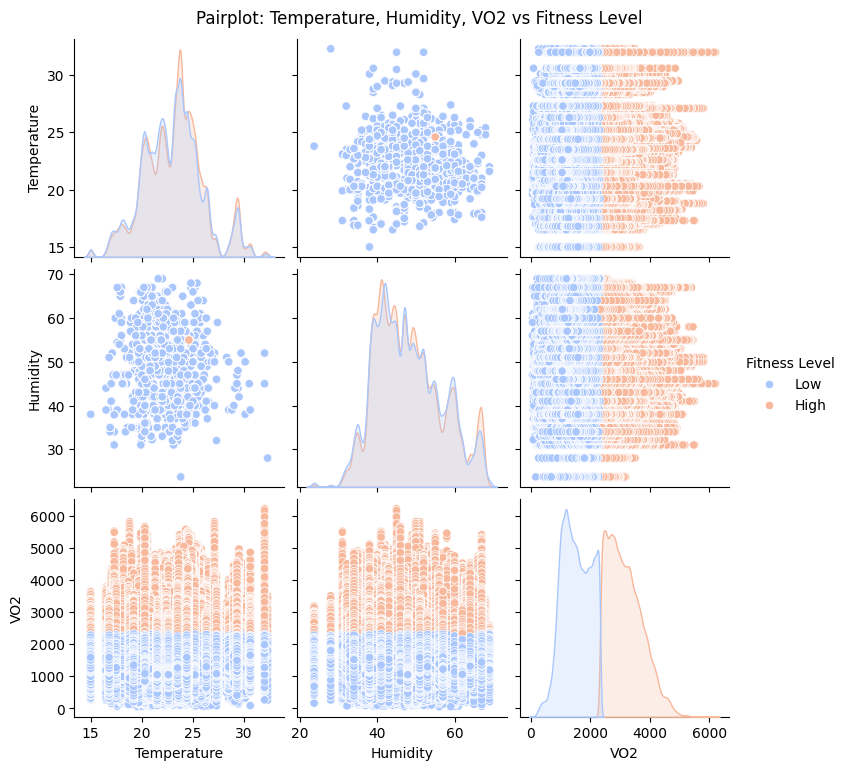

In [70]:
#48."Use a pairplot to analyze the relationship between temperature, humidity, and  VO2 max (ml/kg/min) across different fitness levels
#Hint :Classify ""Fitness Level"" as ""Low"" if VO2 max (ml/kg/min) is below the median, otherwise classify as ""High."

df_merge = pd.merge(df_test, df_subject, on='ID').dropna(subset=['Temperature', 'Humidity', 'VO2'])

#calculating median of VO2
median_vo2 = df_merge['VO2'].median()

#classifying fitness level
def fitness_level(vo2):
    if vo2 < median_vo2:
        return 'Low'
    else:
        return 'High'
    
#Applying the function to create a new column for Fitness Level   
df_merge['Fitness Level'] = df_merge['VO2'].apply(fitness_level)

#Plotting
sns.pairplot(df_merge, vars=['Temperature', 'Humidity', 'VO2'], hue='Fitness Level', palette='coolwarm')
plt.suptitle("Pairplot: Temperature, Humidity, VO2 vs Fitness Level",y=1.02)
plt.show()

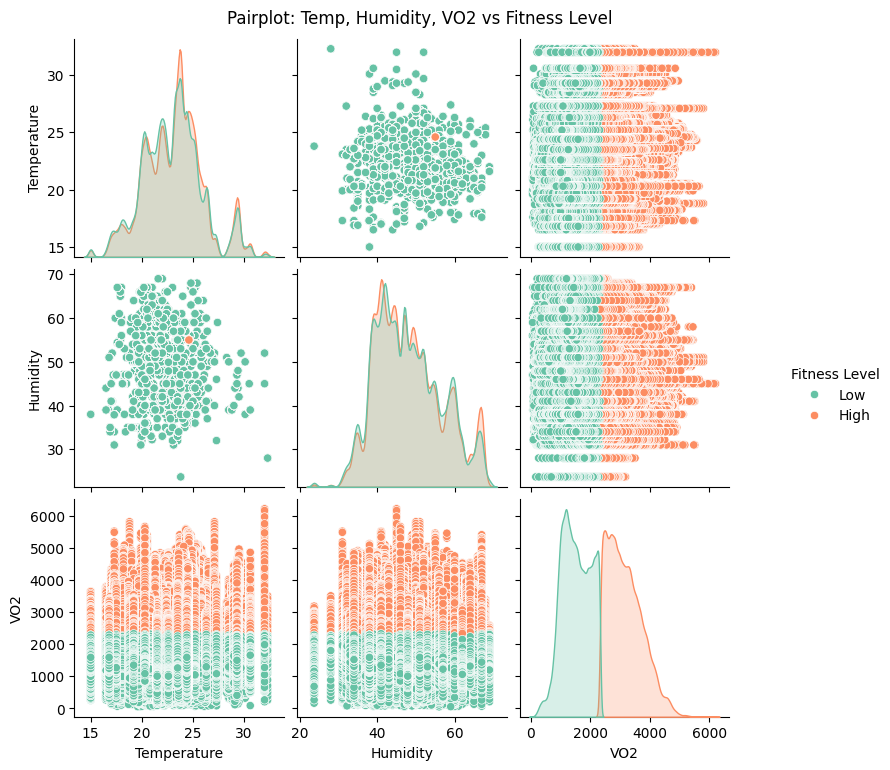

In [73]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load both datasets
df_test = pd.read_csv('test_measure.csv')
df_subject = pd.read_csv('subject-info.csv')

# Step 2: Merge test + subject info on ID
df_merge = pd.merge(df_test, df_subject, on='ID')

# Step 3: Drop missing values in VO2, Temperature, Humidity
df_merge = df_merge.dropna(subset=['VO2', 'Temperature', 'Humidity'])

# Step 4: Calculate VO2 median
median_vo2 = df_merge['VO2'].median()

# Step 5: Define function to classify Fitness Level
def classify_fitness(vo2):
    if vo2 < median_vo2:
        return 'Low'
    else:
        return 'High'

# Step 6: Apply the fitness level function
df_merge['Fitness Level'] = df_merge['VO2'].apply(classify_fitness)

# Step 7: Create the pairplot with clean size
plot = sns.pairplot(
    df_merge,
    vars=['Temperature', 'Humidity', 'VO2'],
    hue='Fitness Level',
    palette='Set2',
    height=2.5  # makes each plot smaller
)

# Step 8: Move the legend to the right side (so it doesn’t overlap the plot)
plot._legend.set_bbox_to_anchor((1.05, 0.5))

# Step 9: Optional title for the full plot
plt.suptitle("Pairplot: Temp, Humidity, VO2 vs Fitness Level", y=1.02)

# Step 10: Show the plot
plt.show()
